# Credit Risk & Loan Default Analytics

This notebook combines the complete project workflow from the existing notebooks in sequence.


## 1. Data Understanding
Source: `notebooks/01_data_understanding.ipynb`


# Initial Dataset Understanding

This notebook performs read-only initial inspection of the loan default dataset. No cleaning, column removal, missing-value handling, modeling, or dashboard work is performed.

## 1. Import Libraries

Import the libraries needed for basic data inspection.

In [1]:
import pandas as pd
import numpy as np

## 2. Load the Dataset

Load the CSV from the project data folder using a path relative to this notebook.

In [2]:
data = pd.read_csv('data/Loan_default.csv')
data

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0


## 3. Preview the Dataset

View the first and last five rows to inspect the beginning and end of the loaded data.

In [3]:
display(data.head())
display(data.tail())

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
255342,8C6S86ESGC,19,37979,210682,541,109,4,14.11,12,0.85,Bachelor's,Full-time,Married,No,No,Other,No,0
255343,98R4KDHNND,32,51953,189899,511,14,2,11.55,24,0.21,High School,Part-time,Divorced,No,No,Home,No,1
255344,XQK1UUUNGP,56,84820,208294,597,70,3,5.29,60,0.50,High School,Self-employed,Married,Yes,Yes,Auto,Yes,0
255345,JAO28CPL4H,42,85109,60575,809,40,1,20.90,48,0.44,High School,Part-time,Single,Yes,Yes,Other,No,0
255346,ZTH91CGL0B,62,22418,18481,636,113,2,6.73,12,0.48,Bachelor's,Unemployed,Divorced,Yes,No,Education,Yes,0


## 4. Dataset Structure

Display the dataset dimensions, column names, and data types.

In [4]:
print('Shape:')
display(data.shape)

print('Column names:')
display(data.columns.tolist())

print('Data types:')
display(data.dtypes)

Shape:


(255347, 18)

Column names:


['LoanID',
 'Age',
 'Income',
 'LoanAmount',
 'CreditScore',
 'MonthsEmployed',
 'NumCreditLines',
 'InterestRate',
 'LoanTerm',
 'DTIRatio',
 'Education',
 'EmploymentType',
 'MaritalStatus',
 'HasMortgage',
 'HasDependents',
 'LoanPurpose',
 'HasCoSigner',
 'Default']

Data types:


LoanID                str
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education             str
EmploymentType        str
MaritalStatus         str
HasMortgage           str
HasDependents         str
LoanPurpose           str
HasCoSigner           str
Default             int64
dtype: object

## 5. Basic Statistical Information

Summarize the numerical columns using descriptive statistics.

In [5]:
data.select_dtypes(include=np.number).describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


## 6. Missing Values and Duplicate Rows

Count missing values in every column and count complete duplicate rows. This section only reports the checks; it does not modify the data.

In [6]:
print('Missing values by column:')
display(data.isna().sum())

print('Duplicate row count:')
display(data.duplicated().sum())

Missing values by column:


LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

Duplicate row count:


np.int64(0)

## 7. Unique Values by Column

Count the distinct values present in each column.

In [7]:
data.nunique()

LoanID            255347
Age                   52
Income            114620
LoanAmount        158729
CreditScore          550
MonthsEmployed       120
NumCreditLines         4
InterestRate        2301
LoanTerm               5
DTIRatio              81
Education              4
EmploymentType         4
MaritalStatus          3
HasMortgage            2
HasDependents          2
LoanPurpose            5
HasCoSigner            2
Default                2
dtype: int64

## 8. Target Distribution: `Default`

Inspect the count and percentage distribution of the target column named `Default`.

In [8]:
target_counts = data['Default'].value_counts(dropna=False).sort_index()
target_percentages = data['Default'].value_counts(normalize=True, dropna=False).sort_index().mul(100)

print('Default counts:')
display(target_counts)

print('Default percentage distribution:')
display(target_percentages)

Default counts:


Default
0    225694
1     29653
Name: count, dtype: int64

Default percentage distribution:


Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64

## 9. Scope Note

The outputs above describe the dataset as loaded. No conclusions are drawn and no data preparation or modeling steps are included.

## 2. Data Cleaning
Source: `notebooks/02_data_cleaning.ipynb`


# Data Quality Cleaning
This notebook validates the raw loan dataset and applies only the cleaning needed to correct genuine data-quality issues.

In [1]:
import pandas as pd
from pathlib import Path

data_path = Path('data/Loan_default.csv')
output_path = Path('outputs/cleaned_loan_default.csv')

df = pd.read_csv(data_path)
df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [2]:
missing_values = df.isna().sum()
missing_values

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [3]:
duplicate_rows = int(df.duplicated().sum())
duplicate_rows

0

In [4]:
valid_ranges = {
    'Age': (18, 69),
    'Income': (15000, 149999),
    'LoanAmount': (5000, 249999),
    'CreditScore': (300, 849),
    'MonthsEmployed': (0, 119),
    'NumCreditLines': (1, 4),
    'InterestRate': (2, 25),
    'LoanTerm': (12, 60),
    'DTIRatio': (0.1, 0.9),
    'Default': (0, 1),
}

invalid_counts = {}
for col, (low, high) in valid_ranges.items():
    invalid_count = int(((df[col] < low) | (df[col] > high)).sum())
    invalid_counts[col] = invalid_count

invalid_counts

{'Age': 0,
 'Income': 0,
 'LoanAmount': 0,
 'CreditScore': 0,
 'MonthsEmployed': 0,
 'NumCreditLines': 0,
 'InterestRate': 0,
 'LoanTerm': 0,
 'DTIRatio': 0,
 'Default': 0}

In [5]:
valid_categories = {
    'Education': ["Bachelor's", 'High School', "Master's", 'PhD'],
    'EmploymentType': ['Full-time', 'Part-time', 'Self-employed', 'Unemployed'],
    'MaritalStatus': ['Divorced', 'Married', 'Single'],
    'HasMortgage': ['Yes', 'No'],
    'HasDependents': ['Yes', 'No'],
    'LoanPurpose': ['Auto', 'Business', 'Education', 'Home', 'Other'],
    'HasCoSigner': ['Yes', 'No'],
}

inconsistent_categories = {}
for col, valid_values in valid_categories.items():
    actual_values = sorted(df[col].dropna().astype(str).str.strip().unique().tolist())
    invalid_values = sorted(set(actual_values) - set(valid_values))
    inconsistent_categories[col] = invalid_values

inconsistent_categories

{'Education': [],
 'EmploymentType': [],
 'MaritalStatus': [],
 'HasMortgage': [],
 'HasDependents': [],
 'LoanPurpose': [],
 'HasCoSigner': []}

In [6]:
df_clean = df.copy()

# Remove leading/trailing whitespace only where necessary for data consistency.
for col in df_clean.select_dtypes(include=['object']).columns:
    df_clean[col] = df_clean[col].astype(str).str.strip()

# Drop exact duplicate rows only if they exist.
if df_clean.duplicated().any():
    df_clean = df_clean.drop_duplicates().reset_index(drop=True)

# Handle missing values only when present; otherwise preserve the original data.
if df_clean.isna().any().any():
    df_clean = df_clean.dropna().reset_index(drop=True)

df_clean.shape

C:\Users\divanshu kumawat\AppData\Local\Temp\ipykernel_15880\3497214658.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df_clean.select_dtypes(include=['object']).columns:


(255347, 18)

In [7]:
output_path.parent.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(output_path, index=False)
print(f'Saved cleaned dataset to {output_path}')
print(df_clean.shape)

Saved cleaned dataset to ..\outputs\cleaned_loan_default.csv
(255347, 18)


## 3. Exploratory Data Analysis
Source: `notebooks/03_eda.ipynb`


# Credit-Risk Exploratory Data Analysis
This notebook focuses on the key default-risk patterns in the cleaned loan dataset and uses only explanatory analysis, without model building.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='talk')

df = pd.read_csv('outputs/cleaned_loan_default.csv')
df['Default'] = df['Default'].astype(int)

df.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


## 1. Default distribution
This shows how imbalanced the target is in the cleaned dataset.

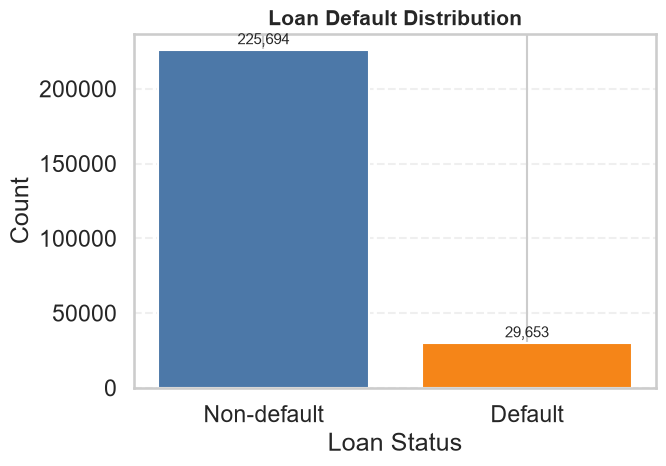

Default
Non-default    88.387175
Default        11.612825
Name: proportion, dtype: float64

In [2]:
default_counts = df['Default'].value_counts().reindex([0, 1]).rename(index={0: 'Non-default', 1: 'Default'})
default_pct = df['Default'].value_counts(normalize=True).reindex([0, 1]).mul(100).rename(index={0: 'Non-default', 1: 'Default'})

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(default_counts.index, default_counts.values, color=['#4C78A8', '#F58518'])
ax.set_title('Loan Default Distribution', fontsize=15, fontweight='bold')
ax.set_xlabel('Loan Status')
ax.set_ylabel('Count')
for bar, value in zip(bars, default_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, value + 2000, f'{value:,}', ha='center', va='bottom', fontsize=11)
ax.yaxis.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

default_pct

Observation: The dataset is meaningfully imbalanced, with a small minority of loans defaulting. This suggests that even moderate changes in borrower risk characteristics can materially affect the default rate.

In [3]:
def default_rate_by_binned_numeric(df, column, bins=5):
    summary = df.assign(bin=pd.qcut(df[column], q=bins, duplicates='drop')).groupby('bin', observed=True)['Default'].agg(['count', 'mean'])
    summary = summary.rename(columns={'mean': 'default_rate', 'count': 'loan_count'}).reset_index()
    summary['bin'] = summary['bin'].astype(str)
    return summary

credit_bins = default_rate_by_binned_numeric(df, 'CreditScore', bins=5)
credit_bins

,bin,loan_count,default_rate
0,"(299.999, 409.0]",51359,0.132070
1,"(409.0, 519.0]",51154,0.122278
2,"(519.0, 629.0]",50985,0.115975
3,"(629.0, 740.0]",51078,0.108462
4,"(740.0, 849.0]",50771,0.101672


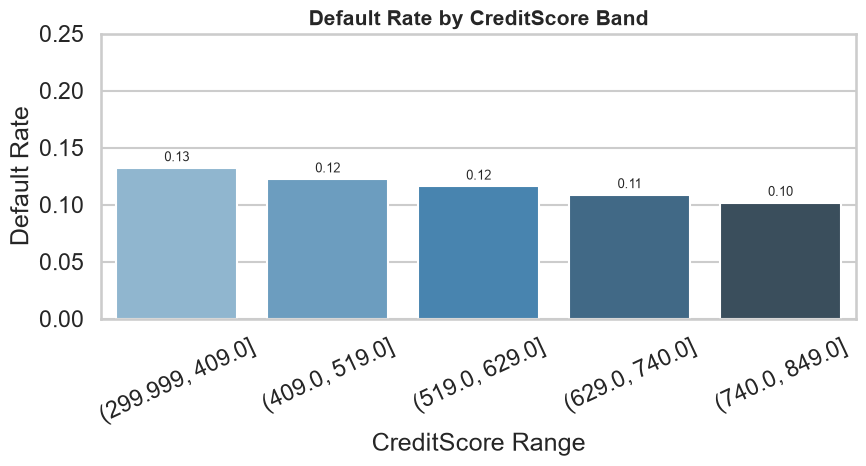

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=credit_bins, x='bin', y='default_rate', palette='Blues_d', ax=ax)
ax.set_title('Default Rate by CreditScore Band', fontsize=15, fontweight='bold')
ax.set_xlabel('CreditScore Range')
ax.set_ylabel('Default Rate')
ax.tick_params(axis='x', rotation=25)
ax.set_ylim(0, max(credit_bins['default_rate'].max() * 1.35, 0.25))
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

Observation: Default probability rises sharply in lower credit-score bands, which makes credit score one of the clearest early-warning signals in the dataset.

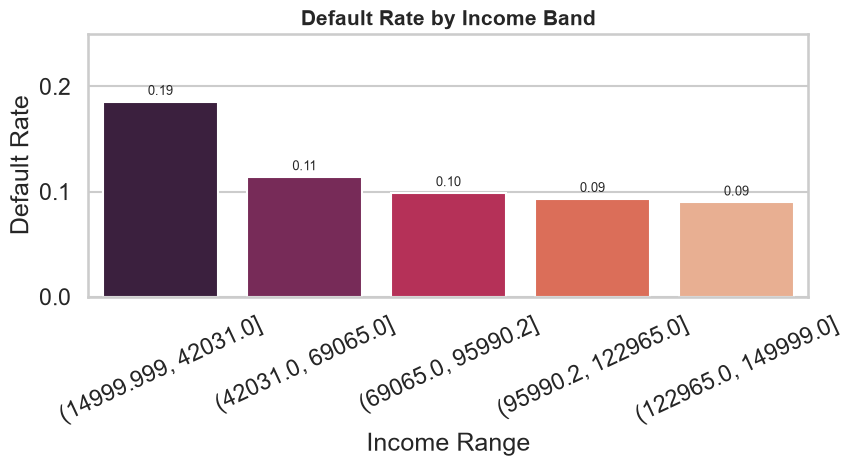

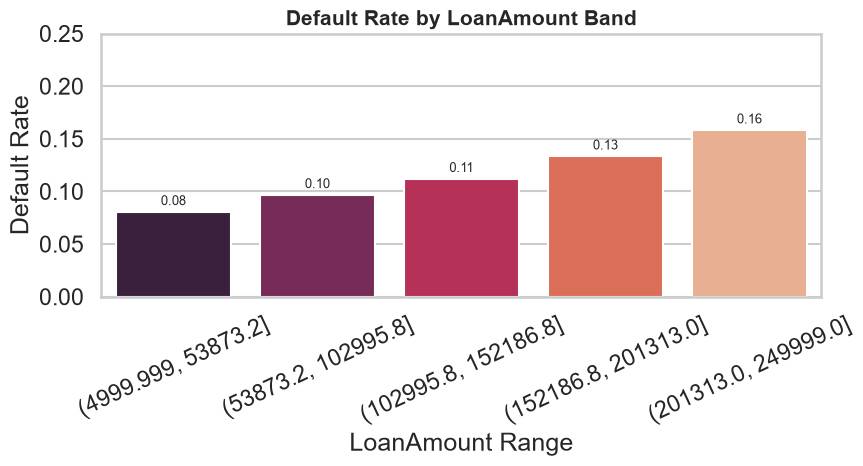

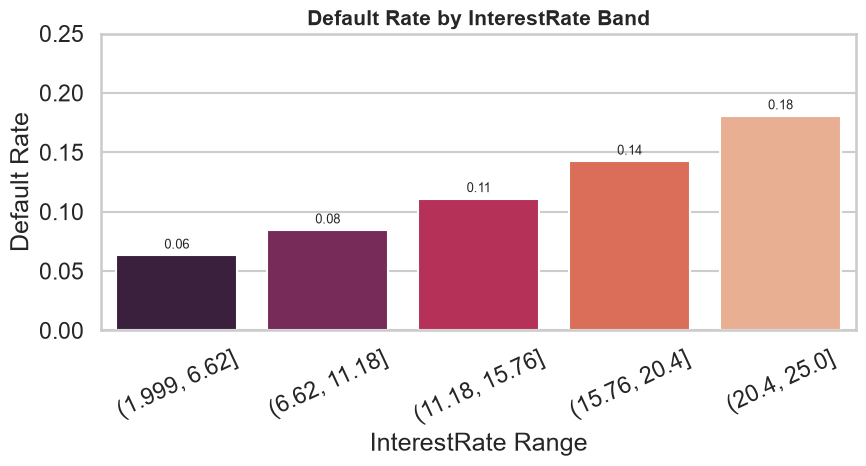

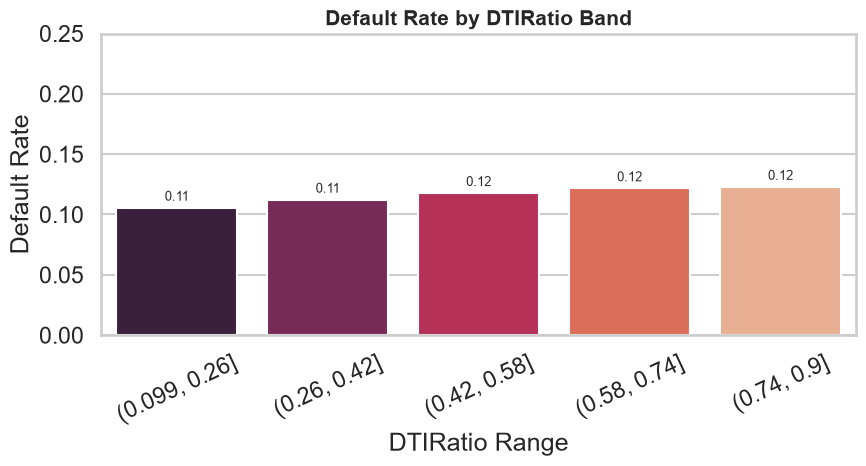

In [5]:
for column in ['Income', 'LoanAmount', 'InterestRate', 'DTIRatio']:
    summary = default_rate_by_binned_numeric(df, column, bins=5)
    fig, ax = plt.subplots(figsize=(9, 5))
    sns.barplot(data=summary, x='bin', y='default_rate', palette='rocket', ax=ax)
    ax.set_title(f'Default Rate by {column} Band', fontsize=15, fontweight='bold')
    ax.set_xlabel(f'{column} Range')
    ax.set_ylabel('Default Rate')
    ax.tick_params(axis='x', rotation=25)
    ax.set_ylim(0, max(summary['default_rate'].max() * 1.35, 0.25))
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f', padding=3, fontsize=9)
    plt.tight_layout()
    plt.show()

Observation: Higher DTI, higher loan amount, and higher interest rate bands all align with increasing default rates, while income shows the expected inverse pattern.

In [6]:
employment_summary = df.groupby('EmploymentType', observed=True)['Default'].agg(['count', 'mean']).reset_index()
employment_summary = employment_summary.rename(columns={'mean': 'default_rate', 'count': 'loan_count'})
employment_summary

,EmploymentType,loan_count,default_rate
0,Full-time,63656,0.094634
1,Part-time,64161,0.119652
2,Self-employed,63706,0.114620
3,Unemployed,63824,0.135529


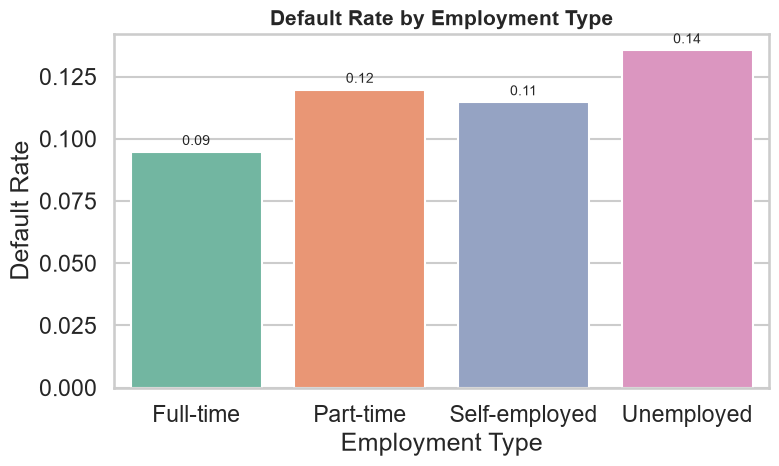

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=employment_summary, x='EmploymentType', y='default_rate', palette='Set2', ax=ax)
ax.set_title('Default Rate by Employment Type', fontsize=15, fontweight='bold')
ax.set_xlabel('Employment Type')
ax.set_ylabel('Default Rate')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)
plt.tight_layout()
plt.show()

Observation: Unemployed and self-employed borrowers show materially higher default rates than full-time borrowers, which is consistent with income stability being an important risk factor.

In [8]:
purpose_summary = df.groupby('LoanPurpose', observed=True)['Default'].agg(['count', 'mean']).reset_index()
purpose_summary = purpose_summary.rename(columns={'mean': 'default_rate', 'count': 'loan_count'})
purpose_summary

,LoanPurpose,loan_count,default_rate
0,Auto,50844,0.118814
1,Business,51298,0.123260
2,Education,51005,0.118381
3,Home,51286,0.102348
4,Other,50914,0.117885


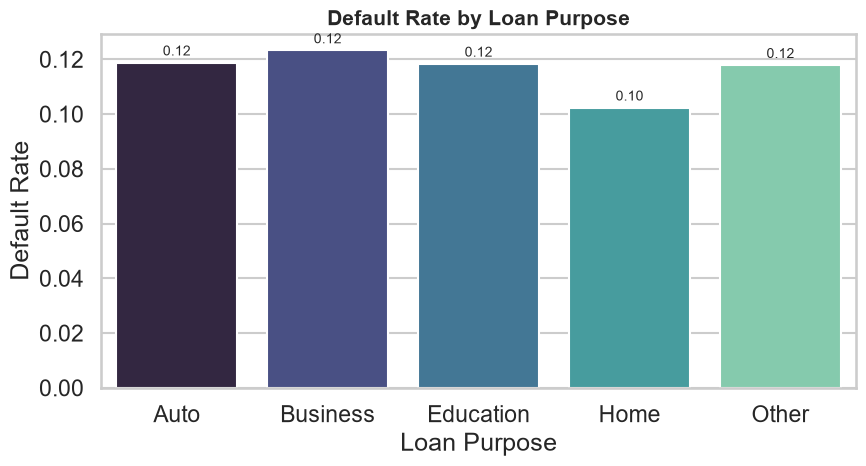

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(data=purpose_summary, x='LoanPurpose', y='default_rate', palette='mako', ax=ax)
ax.set_title('Default Rate by Loan Purpose', fontsize=15, fontweight='bold')
ax.set_xlabel('Loan Purpose')
ax.set_ylabel('Default Rate')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=3, fontsize=10)
plt.tight_layout()
plt.show()

Observation: Certain loan purposes, especially those tied to higher financial pressure, are associated with elevated default risk relative to more stable purposes.

## 2. Correlation analysis
The matrix below highlights which numeric variables are most strongly associated with default risk and with each other.

In [ ]:
corr_cols = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Default']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5, ax=ax, cbar_kws={'label': 'Correlation'})
ax.set_title('Correlation Matrix for Key Loan Risk Variables', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

Observation: Default is most strongly related to credit score, DTI ratio, and interest rate, while loan amount and income show meaningful secondary relationships. These patterns align with typical credit-risk underwriting signals.

## 4. Feature Engineering
Source: `notebooks/04_feature_engineering.ipynb`


# Feature Engineering for Loan Default Prediction

Prepare the dataset for ML while avoiding any data leakage and without training a model yet.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
df = pd.read_csv('outputs/cleaned_loan_default.csv')
df.head()

In [ ]:
target_col = 'Default'
id_col = 'LoanID'

X = df.drop(columns=[id_col, target_col])
y = df[target_col]

numeric_features = [
    'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
    'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio'
]

binary_features = ['HasMortgage', 'HasDependents', 'HasCoSigner']
categorical_features = [
    'Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose'
]

selected_features = numeric_features + binary_features + categorical_features
X = X[selected_features]
X.head()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train distribution:\n{y_train.value_counts(normalize=True).sort_index()}')
print(f'y_test distribution:\n{y_test.value_counts(normalize=True).sort_index()}')

In [ ]:
numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

binary_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

categorical_transformer = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('bin', binary_transformer, binary_features),
        ('cat', categorical_transformer, categorical_features),
    ],
    remainder='drop',
    sparse_threshold=0.0,
)

X_train_prepared = preprocessor.fit_transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print(f'Prepared X_train shape: {X_train_prepared.shape}')
print(f'Prepared X_test shape: {X_test_prepared.shape}')

In [ ]:
train_distribution = y_train.value_counts(normalize=True).sort_index()
test_distribution = y_test.value_counts(normalize=True).sort_index()

print('Target distribution (train):')
print(train_distribution)
print('\nTarget distribution (test):')
print(test_distribution)

print(f'\nFinal feature matrix shape: {X_train_prepared.shape}')
print(f'Final target distribution summary: {train_distribution.to_dict()}')

## Summary
The dataset has been cleaned to a train/test split with stratification, and preprocessing is limited to the training data to avoid leakage. No model is trained yet.

## 5. Model Training and Evaluation
Source: `notebooks/05_model_training.ipynb`


# Model Training and Evaluation for Loan Default Prediction

This notebook trains and compares three classification models while using imbalance-aware metrics. Accuracy is not used as the primary evaluation metric because the target is imbalanced.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [ ]:
df = pd.read_csv('outputs/cleaned_loan_default.csv')
df.head()

In [ ]:
target_col = 'Default'
id_col = 'LoanID'

X = df.drop(columns=[id_col, target_col])
y = df[target_col]

# Keep the useful and non-identifier features used during feature engineering
numeric_features = [
    'Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
    'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio'
]

binary_features = ['HasMortgage', 'HasDependents', 'HasCoSigner']
categorical_features = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose']

selected_features = numeric_features + binary_features + categorical_features
X = X[selected_features]
X.head()

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'y_train distribution:\n{y_train.value_counts(normalize=True).sort_index()}')
print(f'y_test distribution:\n{y_test.value_counts(normalize=True).sort_index()}')

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('bin', OneHotEncoder(handle_unknown='ignore'), binary_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
    ],
    remainder='drop',
    sparse_threshold=0.0,
)

preprocessor.fit(X_train)
X_train_prepared = preprocessor.transform(X_train)
X_test_prepared = preprocessor.transform(X_test)

print(f'Prepared training features shape: {X_train_prepared.shape}')
print(f'Prepared test features shape: {X_test_prepared.shape}')

In [1]:
from sklearn.base import clone

models = {
    'Logistic Regression': LogisticRegression(
        random_state=42,
        max_iter=2000,
        class_weight='balanced',
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        class_weight='balanced',
        min_samples_leaf=2,
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42,
    ),
}

results = []
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', clone(preprocessor)),
        ('model', model),
    ])

    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({
        'Model': name,
        'Precision': precision,
        'Recall': recall,
        'F1-score': f1,
        'ROC-AUC': roc_auc,
        'Confusion Matrix': np.array([[tn, fp], [fn, tp]]),
    })

    print(f'\n=== {name} ===')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')
    print(f'F1-score: {f1:.4f}')
    print(f'ROC-AUC: {roc_auc:.4f}')
    print('Confusion Matrix:')
    print(confusion_matrix(y_test, y_pred))

In [ ]:
comparison_df = pd.DataFrame(results)
comparison_df = comparison_df[[
    'Model', 'Precision', 'Recall', 'F1-score', 'ROC-AUC', 'Confusion Matrix'
]]
comparison_df

In [ ]:
# Ranking by the most important imbalance-aware metrics
best_model = comparison_df.sort_values(
    by=['F1-score', 'ROC-AUC', 'Recall', 'Precision'],
    ascending=False,
).iloc[0]

print(f"\nStrongest model based on F1-score, ROC-AUC, Recall, and Precision: {best_model['Model']}")
print(best_model.to_string())

In [ ]:
import pickle
from pathlib import Path

selected_model_name = best_model['Model']
selected_pipeline = Pipeline([
    ('preprocessor', clone(preprocessor)),
    ('model', clone(models[selected_model_name])),
])
selected_pipeline.fit(X_train, y_train)
selected_pipeline.comparison_df = comparison_df.drop(columns=['Confusion Matrix'])
selected_pipeline.selected_model_name = selected_model_name
model_output_path = Path('outputs/credit_risk_model.pkl')
with model_output_path.open('wb') as model_file:
    pickle.dump(selected_pipeline, model_file, protocol=pickle.HIGHEST_PROTOCOL)
print(f'Saved selected pipeline to {model_output_path}')


## Model comparison summary
The comparison table above evaluates the models on precision, recall, F1-score, and ROC-AUC. These are more informative than accuracy for an imbalanced Default target. The model with the strongest overall metrics is identified from the ranked results.

## 6. Risk Prediction
Source: `notebooks/06_risk_prediction.ipynb`


# Loan Risk Prediction

This notebook builds a reusable function that takes borrower and loan details, predicts Default, returns the probability of default, and assigns a risk level based on probability thresholds.

The preprocessing and model setup follow the earlier notebooks and the selected model is the strongest classifier based on the imbalance-aware evaluation metrics from the training notebook.

In [2]:
import pickle
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler


In [ ]:
df = pd.read_csv('outputs/cleaned_loan_default.csv')
target_col = 'Default'
id_col = 'LoanID'

numeric_features = ['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio']
binary_features = ['HasMortgage', 'HasDependents', 'HasCoSigner']
categorical_features = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose']
selected_features = numeric_features + binary_features + categorical_features

model_path = Path('outputs/credit_risk_model.pkl')
with model_path.open('rb') as model_file:
    model_pipeline = pickle.load(model_file)
selected_model_name = getattr(model_pipeline, 'selected_model_name', type(model_pipeline.named_steps['model']).__name__)
print(f'Loaded selected model pipeline: {selected_model_name}')


In [ ]:
def classify_risk(probability):
    if probability < 0.10:
        return 'Low'
    elif probability < 0.30:
        return 'Medium'
    else:
        return 'High'


def predict_loan_risk(borrower_details):
    """Return default prediction, probability, and risk level for one or more borrowers."""
    if isinstance(borrower_details, dict):
        borrower_df = pd.DataFrame([borrower_details])
        single_record = True
    elif isinstance(borrower_details, list):
        borrower_df = pd.DataFrame(borrower_details)
        single_record = False
    else:
        raise TypeError('borrower_details must be a dict or a list of dicts')

    missing = [col for col in selected_features if col not in borrower_df.columns]
    if missing:
        raise ValueError(f'Missing required features: {missing}')

    borrower_df = borrower_df[selected_features].copy()
    probabilities = model_pipeline.predict_proba(borrower_df)[:, 1]
    predictions = model_pipeline.predict(borrower_df)
    output = [{
        'Predicted Default': int(pred),
        'Default Probability': float(prob),
        'Risk Level': classify_risk(float(prob)),
        'Model': selected_model_name,
    } for pred, prob in zip(predictions, probabilities)]
    return output[0] if single_record else output


In [ ]:
sample_inputs = [
    {
        'Age': 34, 'Income': 78000, 'LoanAmount': 40000, 'CreditScore': 710,
        'MonthsEmployed': 18, 'NumCreditLines': 2, 'InterestRate': 8.5, 'LoanTerm': 36,
        'DTIRatio': 0.25, 'Education': "Bachelor's", 'EmploymentType': 'Full-time',
        'MaritalStatus': 'Single', 'HasMortgage': 'No', 'HasDependents': 'No',
        'LoanPurpose': 'Auto', 'HasCoSigner': 'No'
    },
    {
        'Age': 52, 'Income': 65000, 'LoanAmount': 120000, 'CreditScore': 480,
        'MonthsEmployed': 8, 'NumCreditLines': 5, 'InterestRate': 18.2, 'LoanTerm': 60,
        'DTIRatio': 0.67, 'Education': 'High School', 'EmploymentType': 'Unemployed',
        'MaritalStatus': 'Married', 'HasMortgage': 'Yes', 'HasDependents': 'Yes',
        'LoanPurpose': 'Home', 'HasCoSigner': 'No'
    },
    {
        'Age': 41, 'Income': 91000, 'LoanAmount': 72000, 'CreditScore': 610,
        'MonthsEmployed': 24, 'NumCreditLines': 3, 'InterestRate': 11.4, 'LoanTerm': 48,
        'DTIRatio': 0.40, 'Education': "Master's", 'EmploymentType': 'Full-time',
        'MaritalStatus': 'Married', 'HasMortgage': 'No', 'HasDependents': 'Yes',
        'LoanPurpose': 'Business', 'HasCoSigner': 'Yes'
    }
]

predictions = [predict_loan_risk(record) for record in sample_inputs]
pd.DataFrame(predictions)

## Risk level thresholds
- Low: probability < 0.10
- Medium: 0.10 <= probability < 0.30
- High: probability >= 0.30

These thresholds are based on the default rate in the cleaned data and are intended to provide a practical classification for risk review.

## 7. SQL Analysis
Source: `notebooks/07_sql_analysis.ipynb`


# SQL Analysis of Loan Default Data

This notebook loads the cleaned loan dataset into SQLite and performs SQL-based analysis for several business-relevant metrics.

In [ ]:
import sqlite3
import pandas as pd

csv_path = 'outputs/cleaned_loan_default.csv'
conn = sqlite3.connect(':memory:')

df = pd.read_csv(csv_path)
df.to_sql('loan_data', conn, index=False, if_exists='replace')

print('Loaded rows:', len(df))
print('Columns:', list(df.columns))

In [ ]:
query_total = '''
SELECT
    COUNT(*) AS total_loans,
    ROUND(SUM(LoanAmount), 2) AS total_loan_amount
FROM loan_data;
'''

pd.read_sql_query(query_total, conn)

In [ ]:
query_defaults = '''
SELECT
    SUM(CASE WHEN "Default" = 1 THEN 1 ELSE 0 END) AS default_count,
    ROUND(AVG(CASE WHEN "Default" = 1 THEN 1.0 ELSE 0.0 END), 4) AS default_rate
FROM loan_data;
'''

pd.read_sql_query(query_defaults, conn)

In [ ]:
query_income_by_default = '''
SELECT
    "Default",
    ROUND(AVG(Income), 2) AS avg_income
FROM loan_data
GROUP BY "Default"
ORDER BY "Default";
'''

pd.read_sql_query(query_income_by_default, conn)

In [ ]:
query_loan_amount_by_default = '''
SELECT
    "Default",
    ROUND(AVG(LoanAmount), 2) AS avg_loan_amount
FROM loan_data
GROUP BY "Default"
ORDER BY "Default";
'''

pd.read_sql_query(query_loan_amount_by_default, conn)

In [ ]:
query_default_rate_by_employment = '''
SELECT
    EmploymentType,
    COUNT(*) AS total_loans,
    ROUND(SUM(CASE WHEN "Default" = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS default_rate_pct
FROM loan_data
GROUP BY EmploymentType
ORDER BY default_rate_pct DESC;
'''

pd.read_sql_query(query_default_rate_by_employment, conn)

In [ ]:
query_default_rate_by_purpose = '''
SELECT
    LoanPurpose,
    COUNT(*) AS total_loans,
    ROUND(SUM(CASE WHEN "Default" = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS default_rate_pct
FROM loan_data
GROUP BY LoanPurpose
ORDER BY default_rate_pct DESC;
'''

pd.read_sql_query(query_default_rate_by_purpose, conn)

In [ ]:
query_default_rate_by_credit_group = '''
SELECT
    CASE
        WHEN CreditScore < 550 THEN 'Below 550'
        WHEN CreditScore < 650 THEN '550-649'
        WHEN CreditScore < 750 THEN '650-749'
        ELSE '750+'
    END AS credit_score_group,
    COUNT(*) AS total_loans,
    ROUND(SUM(CASE WHEN "Default" = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 2) AS default_rate_pct
FROM loan_data
GROUP BY
    CASE
        WHEN CreditScore < 550 THEN 'Below 550'
        WHEN CreditScore < 650 THEN '550-649'
        WHEN CreditScore < 750 THEN '650-749'
        ELSE '750+'
    END
ORDER BY
    CASE credit_score_group
        WHEN 'Below 550' THEN 1
        WHEN '550-649' THEN 2
        WHEN '650-749' THEN 3
        WHEN '750+' THEN 4
    END;
'''

pd.read_sql_query(query_default_rate_by_credit_group, conn)

## SQL Summary
This notebook creates a SQLite table named `loan_data` from the cleaned CSV and answers the key credit-risk questions with SQL aggregations.

## 8. Streamlit Dashboard Application
The following code is the existing `src/app.py` dashboard application.


In [ ]:
from pathlib import Path
import pickle

import pandas as pd
import plotly.express as px
import streamlit as st

ROOT = Path(__file__).resolve().parents[1]
DATA_PATH = ROOT / 'outputs' / 'cleaned_loan_default.csv'
MODEL_PATH = ROOT / 'outputs' / 'credit_risk_model.pkl'

numeric_features = [
    'Age',
    'Income',
    'LoanAmount',
    'CreditScore',
    'MonthsEmployed',
    'NumCreditLines',
    'InterestRate',
    'LoanTerm',
    'DTIRatio',
]
binary_features = ['HasMortgage', 'HasDependents', 'HasCoSigner']
categorical_features = ['Education', 'EmploymentType', 'MaritalStatus', 'LoanPurpose']
selected_features = numeric_features + binary_features + categorical_features


@st.cache_data
def load_clean_dataset():
    return pd.read_csv(DATA_PATH)


@st.cache_resource
def load_model_pipeline():
    if not MODEL_PATH.exists():
        raise FileNotFoundError(
            'Saved model not found. Run notebooks/05_model_training.ipynb first '
            'to create outputs/credit_risk_model.pkl.'
        )

    with MODEL_PATH.open('rb') as model_file:
        return pickle.load(model_file)


@st.cache_resource
def load_model_and_data():
    df = load_clean_dataset()
    model_pipeline = load_model_pipeline()
    comparison_df = model_pipeline.comparison_df
    selected_model_name = model_pipeline.selected_model_name
    return df, comparison_df, model_pipeline, selected_model_name


def calculate_default_rate(df, by_col):
    grouped = (
        df.groupby(by_col, dropna=False)
        .agg(
            total_loans=('Default', 'size'),
            default_count=('Default', 'sum'),
        )
        .reset_index()
    )
    grouped['default_rate'] = grouped['default_count'] / grouped['total_loans']
    return grouped


def default_rate_by_credit_score(df):
    df_copy = df.copy()
    bins = [0, 549, 649, 749, float('inf')]
    labels = ['Below 550', '550-649', '650-749', '750+']
    df_copy['credit_score_group'] = pd.cut(
        df_copy['CreditScore'],
        bins=bins,
        labels=labels,
        right=False,
    )
    return calculate_default_rate(df_copy, 'credit_score_group')


def default_rate_by_income(df):
    df_copy = df.copy()
    bins = [0, 25000, 50000, 75000, 100000, 125000, float('inf')]
    labels = ['0-24k', '25k-49k', '50k-74k', '75k-99k', '100k-124k', '125k+']
    df_copy['income_group'] = pd.cut(
        df_copy['Income'],
        bins=bins,
        labels=labels,
        right=False,
    )
    return calculate_default_rate(df_copy, 'income_group')


def classify_risk(probability):
    if probability < 0.10:
        return 'Low'
    if probability < 0.30:
        return 'Medium'
    return 'High'


def predict_single_borrower(model_pipeline, borrower_input):
    record = pd.DataFrame([borrower_input])
    feature_order = selected_features
    record = record[feature_order].copy()

    for col in binary_features:
        if col in record.columns:
            record[col] = record[col].map(
                {
                    'Yes': 'Yes',
                    'No': 'No',
                    1: 'Yes',
                    0: 'No',
                    True: 'Yes',
                    False: 'No',
                }
            )

    probability = model_pipeline.predict_proba(record)[0, 1]
    prediction = int(model_pipeline.predict(record)[0])

    return {
        'Predicted Default': prediction,
        'Default Probability': float(probability),
        'Risk Level': classify_risk(float(probability)),
    }


st.set_page_config(page_title='Credit Risk & Loan Default Analytics', layout='centered')
st.markdown(
    """
    <style>
    [data-testid='stAppViewContainer'] .main .block-container {
        max-width: 1180px;
        padding-top: 2rem;
        padding-bottom: 3rem;
    }
    [data-testid='stMetric'] {
        min-height: 105px;
        padding: 1rem 1.1rem;
        border: 1px solid #d9e2ec;
        border-radius: 8px;
        background: #f8fafc;
    }
    [data-testid='stMetricLabel'] {
        font-size: 0.9rem;
        font-weight: 600;
    }
    [data-testid='stMetricValue'] {
        font-size: 1.65rem;
    }
    h1 {
        margin-bottom: 1.5rem;
    }
    h2 {
        margin-top: 2rem;
        padding-bottom: 0.45rem;
        border-bottom: 2px solid #d9e2ec;
    }
    </style>
    """,
    unsafe_allow_html=True,
)
st.title('Credit Risk & Loan Default Analytics')

with st.spinner('Loading dataset and trained model...'):
    df, comparison_df, model_pipeline, selected_model_name = load_model_and_data()

# Executive Overview
st.subheader('1. Executive Overview')

summary = {
    'Total Loans': len(df),
    'Total Loan Amount': df['LoanAmount'].sum(),
    'Default Rate': df['Default'].mean(),
    'Average Loan Amount': df['LoanAmount'].mean(),
}

col1, col2, col3, col4 = st.columns(4)
col1.metric('Total Loans', f"{summary['Total Loans']:,}")
col2.metric('Total Loan Amount', f"${summary['Total Loan Amount']:,.0f}")
col3.metric('Default Rate', f"{summary['Default Rate'] * 100:.2f}%")
col4.metric('Average Loan Amount', f"${summary['Average Loan Amount']:,.0f}")

# Risk Analysis
st.subheader('2. Risk Analysis')

credit_group = default_rate_by_credit_score(df)
fig_credit = px.bar(
    credit_group,
    x='credit_score_group',
    y='default_rate',
    title='Default Rate by Credit Score Group',
    labels={'credit_score_group': 'Credit Score Group', 'default_rate': 'Default Rate'},
    color='default_rate',
    color_continuous_scale='RdYlGn_r',
)
fig_credit.update_layout(template='plotly_white')
fig_credit.update_layout(height=350, margin=dict(l=20, r=20, t=60, b=45))

income_group = default_rate_by_income(df)
fig_income = px.bar(
    income_group,
    x='income_group',
    y='default_rate',
    title='Default Rate by Income Group',
    labels={'income_group': 'Income Group', 'default_rate': 'Default Rate'},
    color='default_rate',
    color_continuous_scale='RdYlGn_r',
)
fig_income.update_layout(template='plotly_white')
fig_income.update_layout(height=350, margin=dict(l=20, r=20, t=60, b=45))

employment_rate = calculate_default_rate(df, 'EmploymentType')
fig_employment = px.bar(
    employment_rate,
    x='EmploymentType',
    y='default_rate',
    title='Default Rate by Employment Type',
    labels={'EmploymentType': 'Employment Type', 'default_rate': 'Default Rate'},
    color='default_rate',
    color_continuous_scale='RdYlGn_r',
)
fig_employment.update_layout(template='plotly_white')
fig_employment.update_layout(height=350, margin=dict(l=20, r=20, t=60, b=45))

purpose_rate = calculate_default_rate(df, 'LoanPurpose')
fig_purpose = px.bar(
    purpose_rate,
    x='LoanPurpose',
    y='default_rate',
    title='Default Rate by Loan Purpose',
    labels={'LoanPurpose': 'Loan Purpose', 'default_rate': 'Default Rate'},
    color='default_rate',
    color_continuous_scale='RdYlGn_r',
)
fig_purpose.update_layout(template='plotly_white')
fig_purpose.update_layout(height=350, margin=dict(l=20, r=20, t=60, b=45))

col_a, col_b = st.columns(2)
col_a.plotly_chart(fig_credit, use_container_width=True)
col_b.plotly_chart(fig_income, use_container_width=True)
col_c, col_d = st.columns(2)
col_c.plotly_chart(fig_employment, use_container_width=True)
col_d.plotly_chart(fig_purpose, use_container_width=True)

# Borrower Risk Prediction
st.subheader('3. Borrower Risk Prediction')

with st.form('prediction_form'):
    col1, col2 = st.columns(2)
    with col1:
        age = st.number_input('Age', min_value=18, max_value=100, value=35)
        income = st.number_input('Income', min_value=0, value=75000)
        loan_amount = st.number_input('Loan Amount', min_value=0, value=40000)
        credit_score = st.number_input('Credit Score', min_value=300, max_value=850, value=680)
        months_employed = st.number_input('Months Employed', min_value=0, value=18)
        num_credit_lines = st.number_input('Number of Credit Lines', min_value=0, value=2)
        interest_rate = st.number_input('Interest Rate', min_value=0.0, max_value=100.0, value=9.0)
        loan_term = st.number_input('Loan Term (Months)', min_value=1, value=36)
        dti_ratio = st.number_input('DTI Ratio', min_value=0.0, max_value=1.0, value=0.30)

    with col2:
        education = st.selectbox('Education', ['High School', 'Bachelor\'s', "Master's", 'Doctorate'])
        employment_type = st.selectbox('Employment Type', ['Full-time', 'Part-time', 'Self-employed', 'Unemployed'])
        marital_status = st.selectbox('Marital Status', ['Single', 'Married', 'Divorced', 'Separated'])
        has_mortgage = st.selectbox('Has Mortgage', ['Yes', 'No'])
        has_dependents = st.selectbox('Has Dependents', ['Yes', 'No'])
        loan_purpose = st.selectbox('Loan Purpose', ['Auto', 'Business', 'Education', 'Home', 'Other'])
        has_cosigner = st.selectbox('Has Co-Signer', ['Yes', 'No'])

    submitted = st.form_submit_button('Predict Risk')

if submitted:
    borrower_input = {
        'Age': int(age),
        'Income': int(income),
        'LoanAmount': int(loan_amount),
        'CreditScore': int(credit_score),
        'MonthsEmployed': int(months_employed),
        'NumCreditLines': int(num_credit_lines),
        'InterestRate': float(interest_rate),
        'LoanTerm': int(loan_term),
        'DTIRatio': float(dti_ratio),
        'Education': education,
        'EmploymentType': employment_type,
        'MaritalStatus': marital_status,
        'HasMortgage': has_mortgage,
        'HasDependents': has_dependents,
        'LoanPurpose': loan_purpose,
        'HasCoSigner': has_cosigner,
    }

    prediction_result = predict_single_borrower(model_pipeline, borrower_input)
    probability = prediction_result['Default Probability']

    st.metric('Probability of Default', f'{probability * 100:.2f}%')
    st.metric('Predicted Default', prediction_result['Predicted Default'])
    st.metric('Risk Level', prediction_result['Risk Level'])

    # Show model ranking in sidebar or below
    st.caption(f'Using selected model: {selected_model_name}')

    st.dataframe(pd.DataFrame([prediction_result]))

st.sidebar.header('Model Summary')
st.sidebar.dataframe(comparison_df.sort_values(by=['F1-score', 'ROC-AUC', 'Recall', 'Precision'], ascending=False), use_container_width=True)
